# Ejercicio 5: Evaluación de los modelos

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay, classification_report,
)

from src.config import OUT_DIR

plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)


## 5.0 Reconstrucción de `X_test` / `y_test` y carga de modelos

In [2]:
df = pd.read_parquet(OUT_DIR / "ml_dataset.parquet")

UMBRAL_ALTA_CIANOBACTERIA = 10.0
df["alta_cianobacteria"] = (df["cianobacteria"] > UMBRAL_ALTA_CIANOBACTERIA).astype(int)

dia_anio = df["fecha"].dt.dayofyear
df["dia_anio_sin"] = np.sin(2 * np.pi * dia_anio / 365)
df["dia_anio_cos"] = np.cos(2 * np.pi * dia_anio / 365)
df["ndvi_x_ndwi"] = df["ndvi"] * df["ndwi"]

NUM_FEATURES = ["green", "nir", "ndvi", "ndwi", "lat", "lon",
                 "dia_anio_sin", "dia_anio_cos", "ndvi_x_ndwi"]
CAT_FEATURES = ["lago"]
FEATURES = NUM_FEATURES + CAT_FEATURES
TARGET = "alta_cianobacteria"

split_info = pd.read_parquet(OUT_DIR / "split_train_test.parquet").set_index("idx_original")
idx_test = split_info.index[split_info["particion"] == "test"]

X_test = df.loc[idx_test, FEATURES]
y_test = df.loc[idx_test, TARGET]

print(f"X_test: {X_test.shape}, % clase positiva: {y_test.mean()*100:.2f}%")


X_test: (161603, 10), % clase positiva: 7.37%


In [3]:
MODELOS_DIR = OUT_DIR / "modelos"

modelos = {
    "Regresión Logística": joblib.load(MODELOS_DIR / "modelo_logreg.joblib"),
    "Random Forest": joblib.load(MODELOS_DIR / "modelo_rf.joblib"),
    "XGBoost": joblib.load(MODELOS_DIR / "modelo_xgb.joblib"),
}
list(modelos.keys())


['Regresión Logística', 'Random Forest', 'XGBoost']

## 5.1 Métricas de evaluación y matriz de confusión por modelo

In [4]:
predicciones = {}
resultados = []

for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    predicciones[nombre] = {"y_pred": y_pred, "y_proba": y_proba}

    resultados.append({
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label=1),
        "recall": recall_score(y_test, y_pred, pos_label=1),
        "f1": f1_score(y_test, y_pred, pos_label=1),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba),
    })

tabla_metricas = pd.DataFrame(resultados).set_index("modelo").round(4)
tabla_metricas


,accuracy,precision,recall,f1,roc_auc,pr_auc
modelo,,,,,,
Regresión Logística,0.8943,0.4037,0.9128,0.5598,0.9548,0.6978
Random Forest,0.9602,0.6655,0.9236,0.7736,0.9900,0.9184
XGBoost,0.9614,0.6736,0.9247,0.7794,0.9899,0.9198


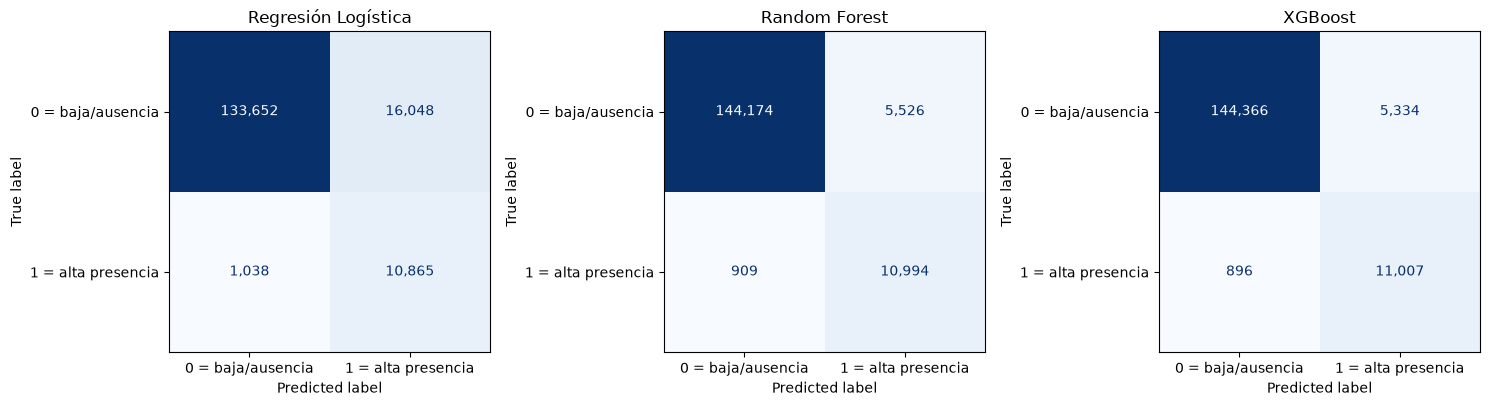

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (nombre, pred) in zip(axes, predicciones.items()):
    cm = confusion_matrix(y_test, pred["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["0 = baja/ausencia", "1 = alta presencia"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=",")
    ax.set_title(nombre)
plt.tight_layout()
plt.show()


In [6]:
for nombre, pred in predicciones.items():
    print(nombre)
    print(classification_report(y_test, pred["y_pred"],
                                 target_names=["0 = baja/ausencia", "1 = alta presencia"],
                                 digits=3))


Regresión Logística
                    precision    recall  f1-score   support

 0 = baja/ausencia      0.992     0.893     0.940    149700
1 = alta presencia      0.404     0.913     0.560     11903

          accuracy                          0.894    161603
         macro avg      0.698     0.903     0.750    161603
      weighted avg      0.949     0.894     0.912    161603

Random Forest
                    precision    recall  f1-score   support

 0 = baja/ausencia      0.994     0.963     0.978    149700
1 = alta presencia      0.665     0.924     0.774     11903

          accuracy                          0.960    161603
         macro avg      0.830     0.943     0.876    161603
      weighted avg      0.970     0.960     0.963    161603

XGBoost
                    precision    recall  f1-score   support

 0 = baja/ausencia      0.994     0.964     0.979    149700
1 = alta presencia      0.674     0.925     0.779     11903

          accuracy                          0.961 

Las tres matrices muestran un comportamiento parecido, algo que era de esperarse debido al desbalance de las clases. Un punto importante es que los tres modelos tienen un Recall bastante similar para la clase positiva: 0.913 para Regresión Logística, 0.924 para Random Forest y 0.925 para XGBoost. Esto indica que los tres modelos logran detectar una proporción similar de las floraciones reales gracias al manejo del desbalance utilizado en el Ejercicio 4.


La principal diferencia está en la Precision. La Regresión Logística tiene una precision de aproximadamente 0.40, mientras que Random Forest y XGBoost llegan a aproximadamente 0.67. Esto significa que la Regresión Logística genera más falsos positivos, es decir, predice que hay una floración cuando en realidad no la hay. Esto puede explicarse porque la Regresión Logística es un modelo lineal y las relaciones entre variables como NDVI y NDWI y la presencia de floraciones parecen ser más complejas y no lineales, como se observó en el Ejercicio 1.5. Por eso, aunque logra detectar bien las floraciones reales, su separación entre las dos clases es menos precisa que la de Random Forest y XGBoost.


## 5.2 Comparación de modelos

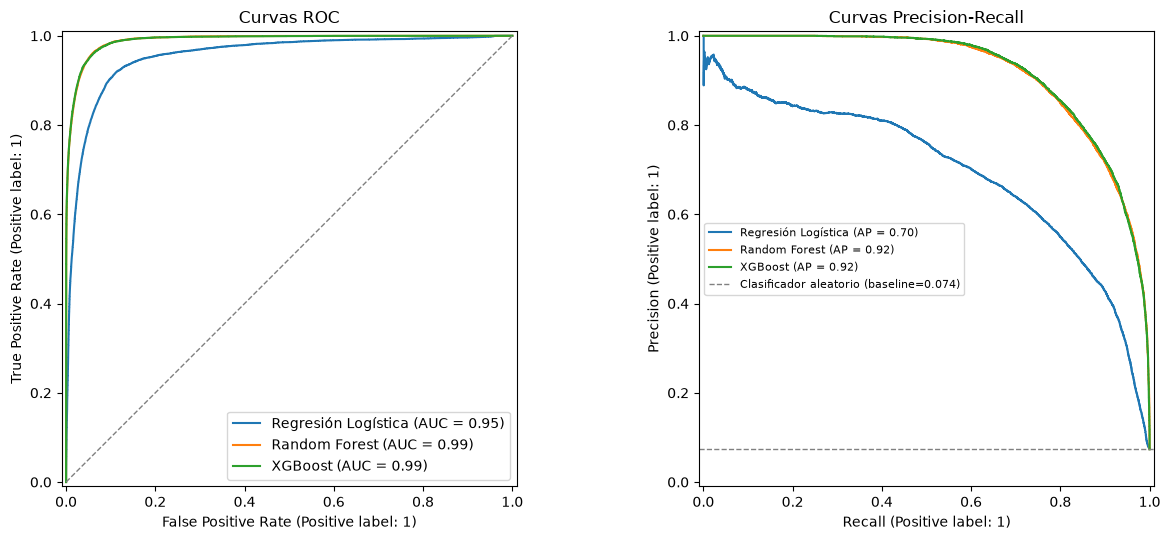

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for nombre, pred in predicciones.items():
    RocCurveDisplay.from_predictions(y_test, pred["y_proba"], name=nombre, ax=axes[0])
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
axes[0].set_title("Curvas ROC")

base_rate = y_test.mean()
for nombre, pred in predicciones.items():
    PrecisionRecallDisplay.from_predictions(y_test, pred["y_proba"], name=nombre, ax=axes[1])
axes[1].axhline(base_rate, linestyle="--", color="gray", linewidth=1,
                 label=f"Clasificador aleatorio (baseline={base_rate:.3f})")
axes[1].set_title("Curvas Precision-Recall")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


Al comparar los tres modelos, podemos ver que Random Forest y XGBoost tienen un mejor desempeño general que la Regresión Logística. Sin embargo, en Recall las diferencias son muy pequeñas, ya que los tres modelos tienen valores entre 0.91 y 0.92. Esto significa que los tres son capaces de detectar una cantidad similar de los casos positivos.


| Modelo              | Recall | Precision |     F1 | PR-AUC |
| ------------------- | -----: | --------: | -----: | -----: |
| Regresión Logística |  0.913 |      0.40 |      — |   0.69 |
| Random Forest       |  0.924 |      0.67 | 0.7736 | 0.9184 |
| XGBoost             |  0.925 |      0.67 | 0.7794 | 0.9198 |

La diferencia más importante está en Precision, F1 y PR-AUC. La Regresión Logística tiene una precision mucho menor, lo que significa que produce más falsos positivos. En cambio, Random Forest y XGBoost mantienen un Recall parecido, pero con menos falsos positivos.

Entre Random Forest y XGBoost la diferencia es bastante pequeña. XGBoost obtiene los mejores valores de F1 y PR-AUC, pero por un margen muy pequeño. Por eso, **XGBoost sería el mejor modelo de los tres**, aunque Random Forest tiene un rendimiento prácticamente igual.

En general, estos resultados muestran que los modelos basados en árboles funcionan mejor que la Regresión Logística para este problema.

## 5.3 Análisis ambiental de los errores y selección de la métrica más adecuada

Falso positivo: ocurre cuando el modelo predice una alta presencia de cianobacteria cuando en realidad es baja o no existe. Esto puede generar alertas innecesarias, muestreos adicionales y posibles restricciones que no eran necesarias, por lo que su costo es principalmente operativo y económico.

Falso negativo: ocurre cuando el modelo no detecta una zona que realmente tiene una alta presencia de cianobacteria. Este error es más grave, ya que una posible floración tóxica podría no generar ninguna alerta y representar un riesgo para las personas y animales.

El error más importante ese el falso negativo, porque es preferible investigar una alerta que termina siendo falsa que no detectar una floración real. Por eso, en este caso es importante darle prioridad al Recall de la clase positiva. Sin embargo, también es importante considerar la PR-AUC, especialmente porque el dataset está desbalanceado y queremos evitar demasiados falsos positivos.